<div style="font-size: 14pt;">Prof. Krzysztof Rybinski</div><br/><br/>
<div style="font-size: 22pt;"><b>Artificial Intelligence course</b></div><br/><br/>
<div style="font-size: 18pt;">Homework 1 </div><br/>
<div style="font-size: 18pt;">- Estimate linear regression model for Boston dataset</div><br/>


# Tasks: 
1. Choose five independent variables from features (X dataframe)
2. State what sign of estimated parameters do you expect and why
3. Estimate a linear regression, with house prices as dependent variable (y)
4. Comment on R2 and statistical significance of estimated parameters
5. Comment on whether your sign expectations (see 2 above) were correct.
6. Send presentation to prof. Rybinski, details on video

In [1]:
from sklearn import datasets
import pandas as pd
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
boston = datasets.load_boston()
pd.DataFrame( boston.data, columns=boston.feature_names ).head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [3]:
boston.DESCR

".. _boston_dataset:\n\nBoston house prices dataset\n---------------------------\n\n**Data Set Characteristics:**  \n\n    :Number of Instances: 506 \n\n    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.\n\n    :Attribute Information (in order):\n        - CRIM     per capita crime rate by town\n        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.\n        - INDUS    proportion of non-retail business acres per town\n        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)\n        - NOX      nitric oxides concentration (parts per 10 million)\n        - RM       average number of rooms per dwelling\n        - AGE      proportion of owner-occupied units built prior to 1940\n        - DIS      weighted distances to five Boston employment centres\n        - RAD      index of accessibility to radial highways\n        - TAX      full-value property-tax rate per $10,000

In [4]:
X = pd.DataFrame(boston.data, columns=boston.feature_names) 

In [5]:
y = pd.DataFrame(boston.target, columns=['Price']) 

In [6]:
X.shape, y.shape

((506, 13), (506, 1))

In [7]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [8]:
y.head()

,Price
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


In [9]:
Price = y["Price"]

In [10]:
#check for multicollinearity, which independent variables (factors) you cannot use together in 
#the model
X.corr()
#list of these variables we can not use together in the model-->["INDUS","NOX","AGE","RAD","TAX"], 
#because we can see the multicollinearity of each variables are higher than 0.7 and lower than -0.7.


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993


In [11]:
#dropping the independent variables (factors) which we cannot use together in 
#the model
X = X.drop(["INDUS","NOX","AGE","RAD","TAX"],axis=1)
X

,CRIM,ZN,CHAS,RM,DIS,PTRATIO,B,LSTAT
0,0.00632,18.0,0.0,6.575,4.0900,15.3,396.90,4.98
1,0.02731,0.0,0.0,6.421,4.9671,17.8,396.90,9.14
2,0.02729,0.0,0.0,7.185,4.9671,17.8,392.83,4.03
3,0.03237,0.0,0.0,6.998,6.0622,18.7,394.63,2.94
4,0.06905,0.0,0.0,7.147,6.0622,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...
501,0.06263,0.0,0.0,6.593,2.4786,21.0,391.99,9.67
502,0.04527,0.0,0.0,6.120,2.2875,21.0,396.90,9.08
503,0.06076,0.0,0.0,6.976,2.1675,21.0,396.90,5.64
504,0.10959,0.0,0.0,6.794,2.3889,21.0,393.45,6.48


In [12]:
#select independent variables, i.e. columns in X dataframe
X = X[["RM","DIS","PTRATIO","B","LSTAT"]]

In [13]:
#check the result with head method
X.head()

,RM,DIS,PTRATIO,B,LSTAT
0,6.575,4.0900,15.3,396.90,4.98
1,6.421,4.9671,17.8,396.90,9.14
2,7.185,4.9671,17.8,392.83,4.03
3,6.998,6.0622,18.7,394.63,2.94
4,7.147,6.0622,18.7,396.90,5.33


In [14]:
#add constant to X
X = sm.add_constant(X)

C:\Users\abel\anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [15]:
#define and fit the model, use sm library
mod = sm.OLS(Price,X)
result = mod.fit()

In [16]:
#print the results
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     235.7
Date:                Mon, 28 Mar 2022   Prob (F-statistic):          5.94e-129
Time:                        08:36:28   Log-Likelihood:                -1533.9
No. Observations:                 506   AIC:                             3080.
Df Residuals:                     500   BIC:                             3105.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.7037      4.284      4.133      0.000       9.287      26.120
RM             4.4538      0.419     10.622      0.000       3.630       5.278
DIS           -0.6152      0.125     -4.904      0.000      -0.862      -0.369
PTRATIO       -0.9423      0.114     -8.256      0.000      -1.167      -0.718
B              0.0120      0.003      4.444      0.000       0.007       0.017
LSTAT         -0.6084      0.048    -12.766      0.000      -0.702      -0.515
==============================================================================
Omnibus:                      184.803   Durbin-Watson:                   0.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              875.877
Skew:                           1.557   Prob(JB):                    6.39e-191
Kurtosis:                       8.643   Cond. No.                     7.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

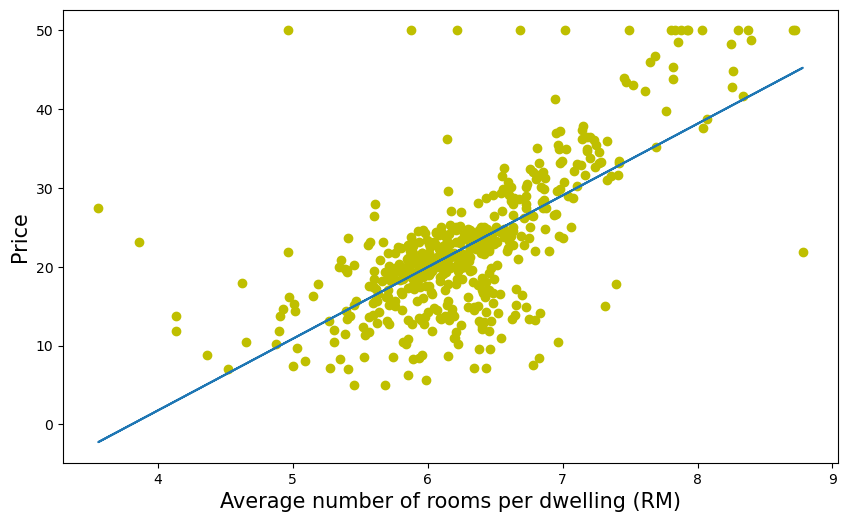

In [17]:
fig = plt.figure(figsize=(10,6),dpi=100)

x = X['RM']
plt.scatter(x,y,c="y")
plt.xlabel("Average number of rooms per dwelling (RM)",fontsize=15)
plt.ylabel("Price",fontsize=15)
m, b = np.polyfit(x,y, 1)
plt.plot(x, m*x + b)
#fig.savefig('RM_linear.png')
plt.show();

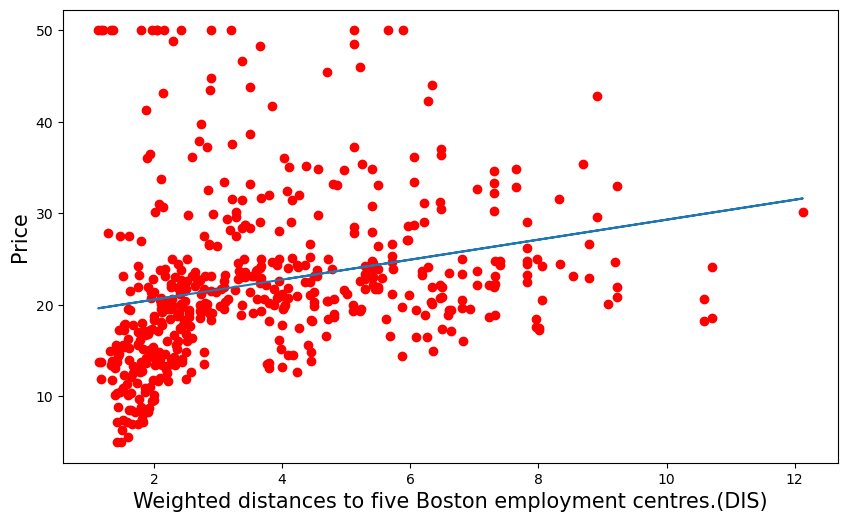

In [98]:
fig = plt.figure(figsize=(10,6),dpi=100)

x = X['DIS']
plt.scatter(x,y,c="r")
plt.xlabel("Weighted distances to five Boston employment centres.(DIS)",fontsize=15)
plt.ylabel("Price",fontsize=15)
m, b = np.polyfit(x,y, 1)
plt.plot(x, m*x + b)
#fig.savefig('DIS_linear.png')
plt.show();

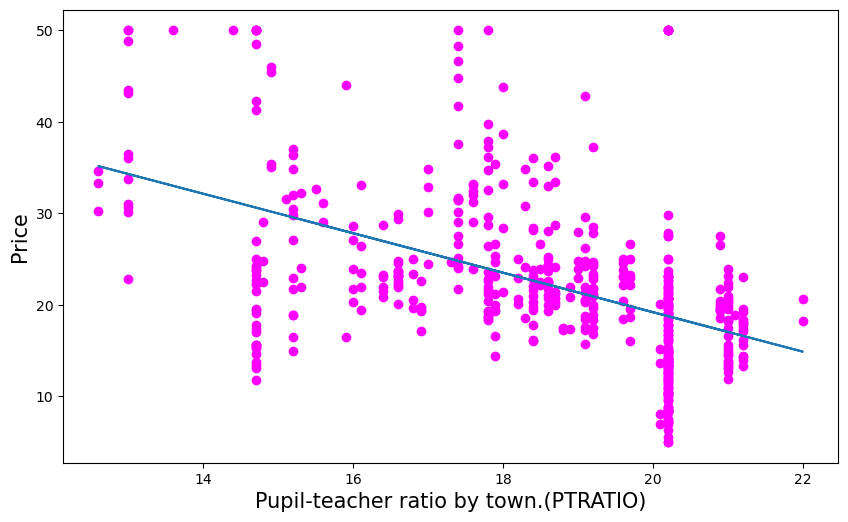

In [99]:
fig = plt.figure(figsize=(10,6),dpi=100)

x = X['PTRATIO']
plt.scatter(x,y,c="magenta")
plt.xlabel("Pupil-teacher ratio by town.(PTRATIO)",fontsize=15)
plt.ylabel("Price",fontsize=15)
m, b = np.polyfit(x,y, 1)
plt.plot(x, m*x + b)
#fig.savefig('PTRATIO_linear.png')
plt.show();

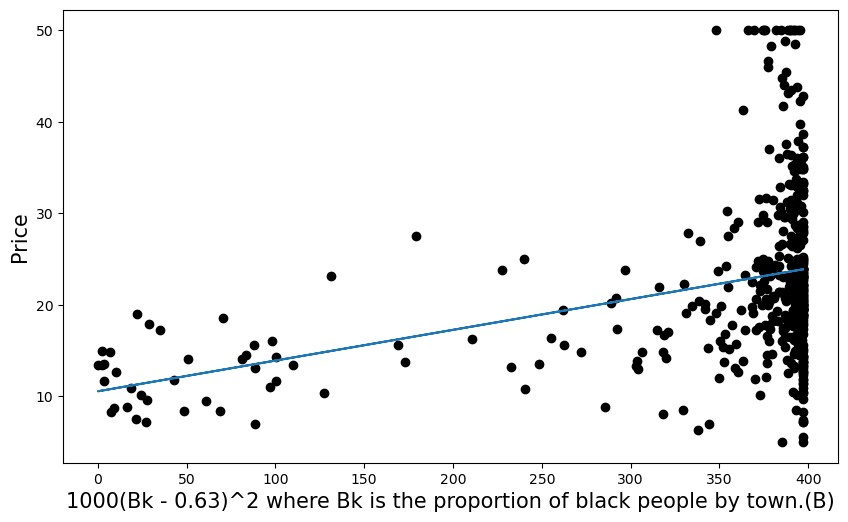

In [100]:
fig = plt.figure(figsize=(10,6),dpi=100)

x = X['B']
plt.scatter(x,y,c="black")
plt.xlabel("1000(Bk - 0.63)^2 where Bk is the proportion of black people by town.(B)",fontsize=15)
plt.ylabel("Price",fontsize=15)
m, b = np.polyfit(x,y, 1)
plt.plot(x, m*x + b)
#fig.savefig('B_linear.png')
plt.show();

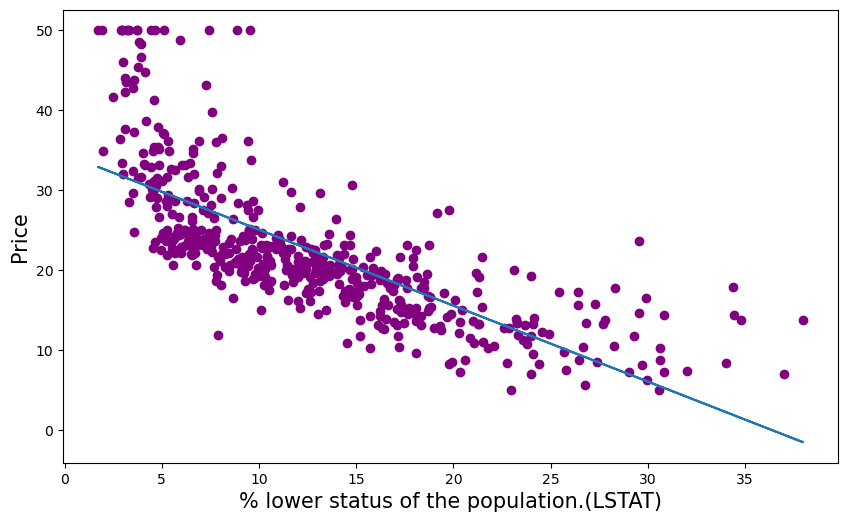

In [101]:
fig = plt.figure(figsize=(10,6),dpi=100)

x = X['LSTAT']
plt.scatter(x,y,c="purple")
plt.xlabel("% lower status of the population.(LSTAT)",fontsize=15)
plt.ylabel("Price",fontsize=15)
m, b = np.polyfit(x,y, 1)
plt.plot(x, m*x + b)
#fig.savefig('LSTAT_linear.png')
plt.show();